# XJTU-SY 故障诊断复现：FFT 特征 + ResCNN-LSTM

参考论文：A Comparative Study of Deep Learning Model Based Equipment Fault Diagnosis and Prognosis。

- 本地 PDF：`../../docs/papers/2025-Qiao-XJTU-Fault-Diagnosis-Prognosis-Comparative-Study.pdf`
- DOI：https://doi.org/10.36001/IJPHM.2025.v16i1.4254

论文的 XJTU-SY fault diagnosis 主线按 FOT 将样本标为 Healthy/Faulty，并以 prediction accuracy 与 F1-score 评估。这里保留框架 demo 流程：配置路径、读取/缓存特征、展示特征图与热力图、构建序列数据集、调用 `BaseTrainer` 训练 ResCNN-LSTM、评估并可视化诊断结果。


## 1. 环境与路径

In [1]:
from pathlib import Path
import random
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch import nn
from torch.utils.data import DataLoader

from phm.data import Dataset
from phm.data.paper import (
    DEFAULT_TIME_FEATURES,
    XJTU_HEALTH_STATES,
    SequenceFeatureDataset,
    build_xjtu_binary_fault_diagnosis_feature_cache,
    fit_feature_standardizer,
    make_sequence_index,
    load_training_artifacts,
    save_training_artifacts,
)
from phm.engine.trainer.BaseTrainer import BaseTrainer
from phm.model.paper import ResCNNLSTMClassifier
from phm.util.Device import select_torch_device


In [2]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / "data" / "loader_roots").exists():
            return path
    raise FileNotFoundError("Could not find data/loader_roots from the current working directory.")

PROJECT_ROOT = find_project_root()
XJTU_ROOT = PROJECT_ROOT / "data" / "loader_roots" / "xjtu"
CACHE_PATH = PROJECT_ROOT / "cache" / "paper_features" / "xjtu_binary_fault_diagnosis_fft256_full.npz"
CHECKPOINT_PATH = PROJECT_ROOT / "cache" / "paper_checkpoints" / "xjtu_rescnn_lstm_binary_fault.pt"
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

SEED = 42
FFT_BINS = 256
SEQUENCE_LENGTH = 8
SEQUENCE_STEP = 1
BATCH_SIZE = 100
MAX_EPOCHS = 35
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
FORCE_REBUILD_CACHE = False
RUN_TRAINING = True
PAPER_XJTU_RESCNN_LSTM_ACCURACY = 0.9639
PAPER_XJTU_RESCNN_LSTM_F1 = 0.964

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = select_torch_device()
print(f"project_root={PROJECT_ROOT}")
print(f"device={device}")


project_root=/Users/nev8r/Desktop/phm2
device=mps


## 2. 全量文件级特征缓存

In [3]:
start_time = time.time()
feature_data = build_xjtu_binary_fault_diagnosis_feature_cache(
    XJTU_ROOT,
    CACHE_PATH,
    fft_bins=FFT_BINS,
    include_handcrafted=True,
    force=FORCE_REBUILD_CACHE,
)
features = feature_data["features"]
targets = feature_data["targets"]
ranges = feature_data["ranges"]
fot_indices = feature_data["metadata"].get("fot_indices", {})
print(f"features={features.shape}, targets={targets.shape}")
print(f"bearings={len(ranges)}, cache={CACHE_PATH}")
print(f"elapsed={time.time() - start_time:.1f}s")
print("fot_indices", fot_indices)


[XJTU-SY diagnosis] processed 500 csv files


[XJTU-SY diagnosis] processed 1000 csv files


[XJTU-SY diagnosis] processed 1500 csv files


[XJTU-SY diagnosis] processed 2000 csv files


[XJTU-SY diagnosis] processed 2500 csv files


...

[XJTU-SY diagnosis] processed 7500 csv files


[XJTU-SY diagnosis] processed 8000 csv files


[XJTU-SY diagnosis] processed 8500 csv files


[XJTU-SY diagnosis] processed 9000 csv files


features=(9216, 552), targets=(9216, 1)
bearings=15, cache=/Users/nev8r/Desktop/phm2/cache/paper_features/xjtu_binary_fault_diagnosis_fft256_full.npz
elapsed=179.8s
fot_indices {'Bearing1_1': 75, 'Bearing1_2': 55, 'Bearing1_3': 74, 'Bearing1_4': 121, 'Bearing1_5': 34, 'Bearing2_1': 454, 'Bearing2_2': 52, 'Bearing2_3': 314, 'Bearing2_4': 30, 'Bearing2_5': 132, 'Bearing3_1': 2386, 'Bearing3_2': 1629, 'Bearing3_3': 342, 'Bearing3_4': 1418, 'Bearing3_5': 10}


## 3. 特征图与热力图

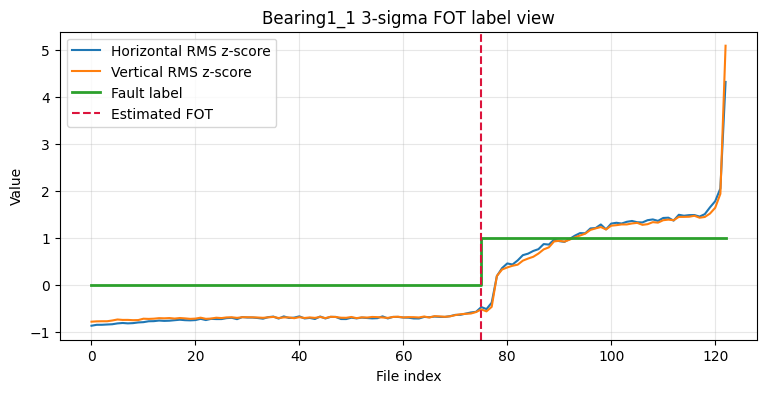

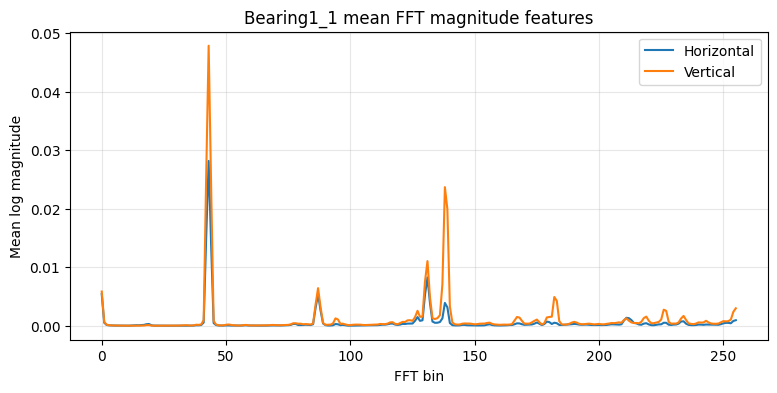

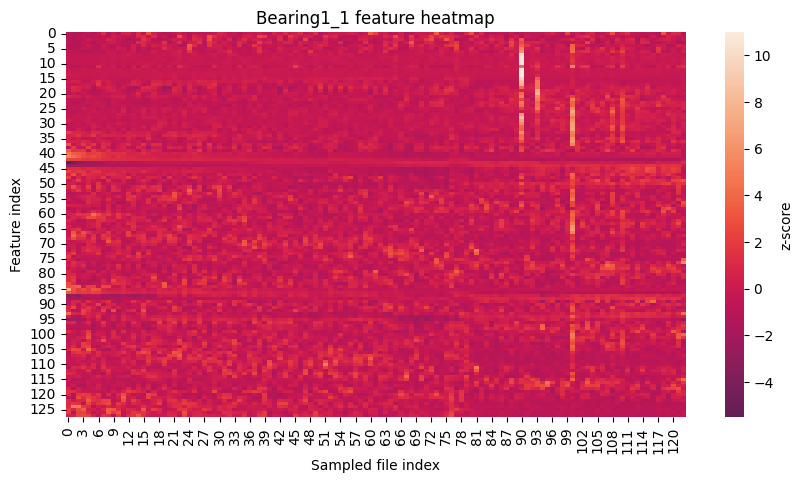

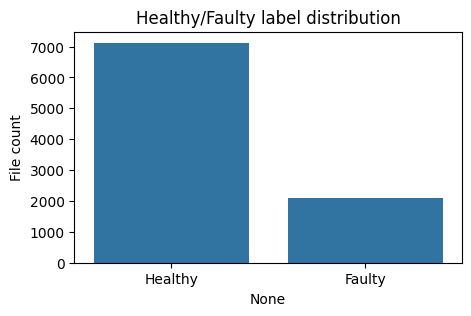

In [4]:
def zscore_for_plot(x):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + 1e-6)

bearing_name = "Bearing1_1"
start, end = ranges[bearing_name]
bearing_features = features[start:end]
bearing_targets = targets[start:end, 0]
channel_width = features.shape[1] // 2
h_rms_index = FFT_BINS + DEFAULT_TIME_FEATURES.index("rms")
v_rms_index = channel_width + FFT_BINS + DEFAULT_TIME_FEATURES.index("rms")
time_axis = np.arange(end - start)
fot_index = int(fot_indices.get(bearing_name, len(bearing_targets)))

plt.figure(figsize=(9, 4))
plt.plot(time_axis, zscore_for_plot(bearing_features[:, [h_rms_index]]).reshape(-1), label="Horizontal RMS z-score")
plt.plot(time_axis, zscore_for_plot(bearing_features[:, [v_rms_index]]).reshape(-1), label="Vertical RMS z-score")
plt.step(time_axis, bearing_targets, where="post", label="Fault label", linewidth=2)
plt.axvline(fot_index, color="crimson", linestyle="--", linewidth=1.5, label="Estimated FOT")
plt.xlabel("File index")
plt.ylabel("Value")
plt.title(f"{bearing_name} 3-sigma FOT label view")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(np.mean(bearing_features[:, :FFT_BINS], axis=0), label="Horizontal")
plt.plot(np.mean(bearing_features[:, channel_width:channel_width + FFT_BINS], axis=0), label="Vertical")
plt.xlabel("FFT bin")
plt.ylabel("Mean log magnitude")
plt.title(f"{bearing_name} mean FFT magnitude features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

stride = max(len(bearing_features) // 240, 1)
heat = zscore_for_plot(bearing_features[::stride, :128]).T
plt.figure(figsize=(10, 5))
sns.heatmap(heat, cmap="rocket", center=0, cbar_kws={"label": "z-score"})
plt.xlabel("Sampled file index")
plt.ylabel("Feature index")
plt.title(f"{bearing_name} feature heatmap")
plt.show()

label_counts = pd.Series(targets.reshape(-1)).map(dict(enumerate(XJTU_HEALTH_STATES))).value_counts().reindex(XJTU_HEALTH_STATES)
plt.figure(figsize=(5, 3))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.ylabel("File count")
plt.title("Healthy/Faulty label distribution")
plt.show()


## 4. 构建序列数据集

In [5]:
windows, window_bearings = make_sequence_index(
    ranges,
    sequence_length=SEQUENCE_LENGTH,
    sequence_step=SEQUENCE_STEP,
)

rng = np.random.default_rng(SEED)
order = rng.permutation(len(windows))
test_size = max(int(len(order) * 0.15), 1)
val_size = max(int(len(order) * 0.15), 1)
test_idx = order[:test_size]
val_idx = order[test_size:test_size + val_size]
train_idx = order[test_size + val_size:]

train_windows = windows[train_idx]
val_windows = windows[val_idx]
test_windows = windows[test_idx]
mean, std = fit_feature_standardizer(features, train_windows)

train_dataset = SequenceFeatureDataset(features, targets, train_windows, mean=mean, std=std)
val_dataset = SequenceFeatureDataset(features, targets, val_windows, mean=mean, std=std)
test_dataset = SequenceFeatureDataset(features, targets, test_windows, mean=mean, std=std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"train_windows={len(train_dataset)}, val_windows={len(val_dataset)}, test_windows={len(test_dataset)}")
print(f"input_dim={features.shape[1]}, classes={XJTU_HEALTH_STATES}")


train_windows=6379, val_windows=1366, test_windows=1366
input_dim=552, classes=('Healthy', 'Faulty')


## 5. 调用框架 Trainer 训练

In [6]:
model = ResCNNLSTMClassifier(
    input_dim=features.shape[1],
    num_classes=len(XJTU_HEALTH_STATES),
    hidden_dim=64,
    conv_channels=64,
    lstm_layers=1,
    residual_blocks=2,
    dropout=0.2,
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
trainer = BaseTrainer(config={
    "device": device,
    "epochs": MAX_EPOCHS,
    "batch_size": BATCH_SIZE,
    "criterion": criterion,
    "optimizer": optimizer,
    "data_loader": train_loader,
    "grad_clip_norm": 1.0,
})

if RUN_TRAINING:
    loss_history = trainer(model, Dataset(name="XJTU-SY binary fault diagnosis ResCNN-LSTM train"))
    save_training_artifacts(
        model,
        CHECKPOINT_PATH,
        mean=mean,
        std=std,
        config={
            "model": "ResCNNLSTMClassifier",
            "task": "binary_fault_diagnosis",
            "fft_bins": FFT_BINS,
            "include_handcrafted": True,
            "sequence_length": SEQUENCE_LENGTH,
            "sequence_step": SEQUENCE_STEP,
            "classes": XJTU_HEALTH_STATES,
            "epochs": MAX_EPOCHS,
            "loss": "CrossEntropyLoss",
            "optimizer": "AdamW",
            "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
        },
    )
else:
    loss_history = {}
    print("RUN_TRAINING=False, skip training")


[INFO    01:06:25]  
[Trainer]  Start training by BaseTrainer:
	training set: XJTU-SY binary fault diagnosis ResCNN-…
	device: mps
	epochs: 35
	batch_size: 100
	criterion: CrossEntropyLoss()
	optimizer: AdamW
	grad_clip_norm: 1.0
	callbacks: []
	dtype: torch.float32
	lr: 0.01
	weight_decay: 0.0


[INFO    01:06:26]  [BaseTrainer]  Epoch [1/35], CrossEntropyLoss:0.1885


[INFO    01:06:27]  [BaseTrainer]  Epoch [2/35], CrossEntropyLoss:0.0462


[INFO    01:06:28]  [BaseTrainer]  Epoch [3/35], CrossEntropyLoss:0.0299


[INFO    01:06:29]  [BaseTrainer]  Epoch [4/35], CrossEntropyLoss:0.0160


...

[INFO    01:06:47]  [BaseTrainer]  Epoch [31/35], CrossEntropyLoss:0.0014


[INFO    01:06:47]  [BaseTrainer]  Epoch [32/35], CrossEntropyLoss:0.0001


[INFO    01:06:48]  [BaseTrainer]  Epoch [33/35], CrossEntropyLoss:0.0004


[INFO    01:06:49]  [BaseTrainer]  Epoch [34/35], CrossEntropyLoss:0.0002


[INFO    01:06:49]  [BaseTrainer]  Epoch [35/35], CrossEntropyLoss:0.0001


## 6. 验证集与测试集评估

In [7]:
def predict_loader(model, loader, device):
    model.to(device)
    model.eval()
    logits_list = []
    labels_list = []
    losses = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.long).reshape(-1)
            logits = model(x)
            loss = criterion(logits, y)
            logits_list.append(logits.cpu().numpy())
            labels_list.append(y.cpu().numpy())
            losses.append(loss.item() * x.size(0))
    logits = np.vstack(logits_list)
    labels = np.concatenate(labels_list)
    prob = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    pred = prob.argmax(axis=1)
    metrics = {
        "loss": float(sum(losses) / len(labels)),
        "accuracy": float(accuracy_score(labels, pred)),
        "macro_f1": float(f1_score(labels, pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(labels, pred, average="weighted", zero_division=0)),
        "fault_f1": float(f1_score(labels, pred, pos_label=1, zero_division=0)),
    }
    return metrics, prob, pred, labels

if CHECKPOINT_PATH.exists():
    load_training_artifacts(model, CHECKPOINT_PATH, map_location=device)

val_metrics, val_prob, val_pred, val_true = predict_loader(model, val_loader, device)
test_metrics, test_prob, test_pred, test_true = predict_loader(model, test_loader, device)
print("val", {k: round(v, 4) for k, v in val_metrics.items()})
print("test", {k: round(v, 4) for k, v in test_metrics.items()})
print(classification_report(test_true, test_pred, target_names=XJTU_HEALTH_STATES, zero_division=0))

paper_reference = pd.DataFrame(
    [{"model": "Paper ResCNN-LSTM", "accuracy": PAPER_XJTU_RESCNN_LSTM_ACCURACY, "f1": PAPER_XJTU_RESCNN_LSTM_F1}],
).set_index("model")
our_reference = pd.DataFrame(
    [{"model": "Ours ResCNN-LSTM", "accuracy": test_metrics["accuracy"], "f1": test_metrics["weighted_f1"]}],
).set_index("model")
display(pd.concat([paper_reference, our_reference]).round(4))


val

{'loss': 0.019, 'accuracy': 0.9985, 'macro_f1': 0.998, 'weighted_f1': 0.9985, 'fault_f1': 0.997}

test

{'loss': 0.0214, 'accuracy': 0.9963, 'macro_f1': 0.9949, 'weighted_f1': 0.9963, 'fault_f1': 0.9922}

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1046
      Faulty       0.99      0.99      0.99       320

    accuracy                           1.00      1366
   macro avg       0.99      1.00      0.99      1366
weighted avg       1.00      1.00      1.00      1366


,accuracy,f1
model,,
Paper ResCNN-LSTM,0.9639,0.9640
Ours ResCNN-LSTM,0.9963,0.9963


## 7. 训练曲线、概率热力图与混淆热力图

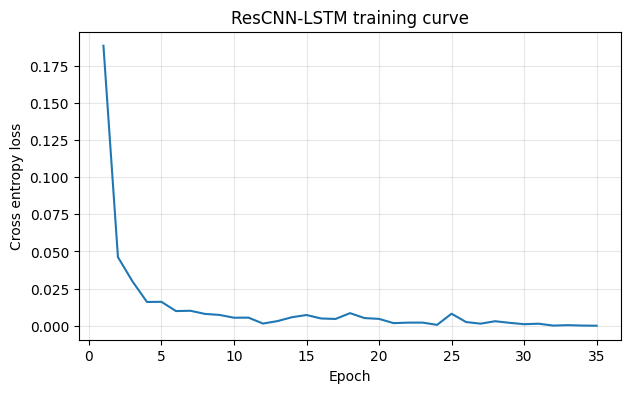

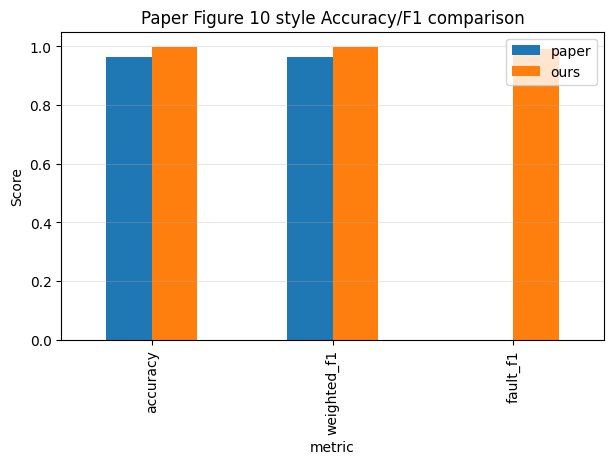

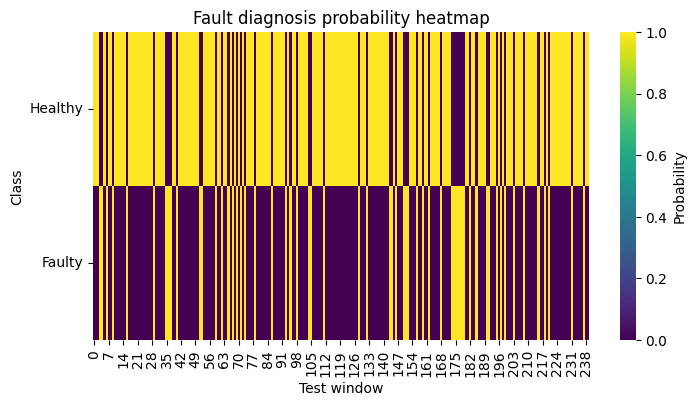

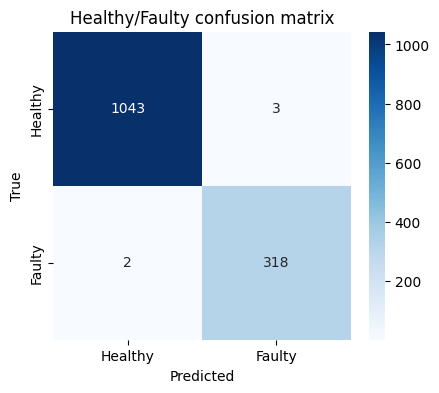

In [8]:
train_losses = next(iter(loss_history.values()), []) if loss_history else []
if train_losses:
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, len(train_losses) + 1), train_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Cross entropy loss")
    plt.title("ResCNN-LSTM training curve")
    plt.grid(alpha=0.3)
    plt.show()

metric_frame = pd.DataFrame(
    [
        {"metric": "accuracy", "paper": PAPER_XJTU_RESCNN_LSTM_ACCURACY, "ours": test_metrics["accuracy"]},
        {"metric": "weighted_f1", "paper": PAPER_XJTU_RESCNN_LSTM_F1, "ours": test_metrics["weighted_f1"]},
        {"metric": "fault_f1", "paper": np.nan, "ours": test_metrics["fault_f1"]},
    ]
).set_index("metric")
plt.figure(figsize=(7, 4))
metric_frame.plot(kind="bar", ax=plt.gca())
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Paper Figure 10 style Accuracy/F1 comparison")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(test_prob[:240].T, cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "Probability"})
plt.yticks(np.arange(len(XJTU_HEALTH_STATES)) + 0.5, XJTU_HEALTH_STATES, rotation=0)
plt.xlabel("Test window")
plt.ylabel("Class")
plt.title("Fault diagnosis probability heatmap")
plt.show()

cm = confusion_matrix(test_true, test_pred, labels=list(range(len(XJTU_HEALTH_STATES))))
plt.figure(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=XJTU_HEALTH_STATES, yticklabels=XJTU_HEALTH_STATES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Healthy/Faulty confusion matrix")
plt.show()
